Download TuSimple dataset from kaggle and extract the labeled data from the dataset and save them to drive.

In [3]:
import os
import json
import shutil
from google.colab import drive

# --- CONFIGURATION ---
# Replace with your Kaggle credentials
os.environ['KAGGLE_USERNAME'] = "themastersifu"
os.environ['KAGGLE_KEY'] = "KGAT_9b16bfeddf69c01fa033fa0cfa69701b"

# Paths
LOCAL_RAW = "/content/tusimple_raw"
DRIVE_PATH = "/content/drive/MyDrive/Lane_Detection_Project/data/tusimple"
ZIP_PATH = "/content/tusimple.zip"

# --- 1. MOUNT DRIVE ---
print("Mounting Google Drive...")
drive.mount('/content/drive')
os.makedirs(DRIVE_PATH, exist_ok=True)

# --- 2. DOWNLOAD & UNZIP LOCALLY (Saves Drive Space) ---
if not os.path.exists(ZIP_PATH):
    print("Downloading dataset from Kaggle...")
    !pip install -q kaggle
    !kaggle datasets download -d manideep1108/tusimple -p /content/
else:
    print("Zip already exists locally. Skipping download.")

if not os.path.exists(LOCAL_RAW):
    print("Unzipping dataset to local disk (this takes ~5 mins)...")
    !unzip -q {ZIP_PATH} -d {LOCAL_RAW}
else:
    print("Dataset already unzipped locally.")

# --- 3. FILTERING LOGIC ---
def extract_labeled_only(source_folder, target_folder, json_files):
    """Copies only labeled images and their JSONs to Drive."""
    total_copied = 0
    
    for j_file in json_files:
        json_path = os.path.join(source_folder, j_file)
        if not os.path.exists(json_path):
            print(f"Warning: {j_file} not found in {source_folder}")
            continue
            
        print(f"Processing {j_file}...")
        with open(json_path, 'r') as f:
            lines = f.readlines()
            
        for line in lines:
            data = json.loads(line)
            rel_path = data['raw_file'] # e.g., 'clips/0313-1/60/20.jpg'
            
            src_img = os.path.join(source_folder, rel_path)
            dst_img = os.path.join(target_folder, rel_path)
            
            # Create subfolders in Drive only if needed
            os.makedirs(os.path.dirname(dst_img), exist_ok=True)
            
            if os.path.exists(src_img):
                shutil.copy(src_img, dst_img)
                total_copied += 1
            
        # Copy the JSON label file itself to Drive
        shutil.copy(json_path, os.path.join(target_folder, j_file))
        
    return total_copied

# --- 4. EXECUTION ---
# TuSimple training set JSONs
train_labels = [
    'label_data_0313.json', 
    'label_data_0531.json', 
    'label_data_0601.json'
]

print("Starting extraction to Drive...")
# The Kaggle unzip usually puts everything inside 'TUSimple/train_set' or similar. 
# Adjust 'source_root' if your unzip structure differs.
source_root = os.path.join(LOCAL_RAW, "TUSimple/train_set") 

count = extract_labeled_only(source_root, os.path.join(DRIVE_PATH, "train_set"), train_labels)

print(f"\nSUCCESS!")
print(f"Total labeled images saved to Drive: {count}")
print(f"Drive path: {DRIVE_PATH}")

# Optional: Clean up the local 25GB zip to free up Colab local disk
# !rm {ZIP_PATH}
# !rm -rf {LOCAL_RAW}

Mounted at /content/drive
Dataset URL: https://www.kaggle.com/datasets/manideep1108/tusimple
License(s): copyright-authors
100% 21.6G/21.6G [03:13<00:00, 120MB/s] 

Unzipping dataset to local disk (this takes ~5 mins)...
Starting extraction to Drive...
Processing label_data_0313.json...
Processing label_data_0531.json...
Processing label_data_0601.json...

SUCCESS!
Total labeled images saved to Drive: 3626
Drive path: /content/drive/MyDrive/Lane_Detection_Project/data/tusimple


Generate and save the masks

In [4]:
import cv2
import numpy as np
import os
import json

def generate_and_save_masks(json_files, root_dir):
    # Create output directories
    bin_out = os.path.join(root_dir, 'seg_label')
    inst_out = os.path.join(root_dir, 'instance_label')
    os.makedirs(bin_out, exist_ok=True)
    os.makedirs(inst_out, exist_ok=True)

    for j_file in json_files:
        with open(os.path.join(root_dir, j_file), 'r') as f:
            for line in f:
                data = json.loads(line)
                raw_path = data['raw_file'] # e.g. "clips/0313-1/60/20.jpg"
                
                # Setup blank masks (720x1280 is TuSimple standard)
                bin_mask = np.zeros((720, 1280), dtype=np.uint8)
                inst_mask = np.zeros((720, 1280), dtype=np.uint8)
                
                lanes = data['lanes']
                y_samples = data['h_samples']
                
                for i, lane in enumerate(lanes):
                    # Filter out -2 (no lane) values
                    points = [[x, y] for x, y in zip(lane, y_samples) if x >= 0]
                    if len(points) < 2: continue
                    
                    pts = np.array([points], np.int32)
                    # Draw on Binary Mask (All white)
                    cv2.polylines(bin_mask, pts, isClosed=False, color=255, thickness=10)
                    # Draw on Instance Mask (Unique values: 50, 100, 150...)
                    cv2.polylines(inst_mask, pts, isClosed=False, color=(i+1)*50, thickness=10)

                # Save to Drive (matching the 'clips' subfolder structure)
                save_bin_path = os.path.join(bin_out, raw_path).replace('.jpg', '.png')
                save_inst_path = os.path.join(inst_out, raw_path).replace('.jpg', '.png')
                
                os.makedirs(os.path.dirname(save_bin_path), exist_ok=True)
                os.makedirs(os.path.dirname(save_inst_path), exist_ok=True)
                
                cv2.imwrite(save_bin_path, bin_mask)
                cv2.imwrite(save_inst_path, inst_mask)

# Execute
ROOT = "/content/drive/MyDrive/Lane_Detection_Project/data/tusimple/train_set"
JSONS = ['label_data_0313.json', 'label_data_0531.json', 'label_data_0601.json']
generate_and_save_masks(JSONS, ROOT)

Download and save the test set to drive

In [5]:
import os
import json
import shutil
from google.colab import drive

# Paths (Assuming project path from previous steps)
PROJECT_ROOT = "/content/drive/MyDrive/Lane_Detection_Project"
DRIVE_TEST_PATH = os.path.join(PROJECT_ROOT, "data/tusimple/test_set")
LOCAL_RAW = "/content/tusimple_raw"
ZIP_PATH = "/content/tusimple.zip"

# --- 1. MOUNT & SETUP ---
if not os.path.exists('/content/drive'):
    drive.mount('/content/drive')
os.makedirs(DRIVE_TEST_PATH, exist_ok=True)

# --- 2. DOWNLOAD & UNZIP (If not already done locally) ---
if not os.path.exists(LOCAL_RAW):
    print("Downloading/Unzipping locally...")
    !pip install -q kaggle
    # Ensure kaggle.json is present or os.environ keys are set from previous step
    !kaggle datasets download -d manideep1108/tusimple -p /content/
    !unzip -q {ZIP_PATH} -d {LOCAL_RAW}

# --- 3. EXTRACT TEST IMAGES ---
def extract_test_subset(source_root, target_root, task_json):
    source_json = os.path.join(source_root, task_json)
    if not os.path.exists(source_json):
        print(f"Error: {task_json} not found!")
        return
    
    with open(source_json, 'r') as f:
        lines = f.readlines()
    
    print(f"Extracting {len(lines)} test images to Drive...")
    for line in lines:
        data = json.loads(line)
        rel_path = data['raw_file']
        
        src = os.path.join(source_root, rel_path)
        dst = os.path.join(target_root, rel_path)
        
        os.makedirs(os.path.dirname(dst), exist_ok=True)
        if os.path.exists(src):
            shutil.copy(src, dst)
            
    # Copy the task JSON itself
    shutil.copy(source_json, os.path.join(target_root, task_json))
    print("Test set extraction complete.")

# Execution - Note: Kaggle unzip usually puts test_set inside 'TUSimple'
source_test_root = os.path.join(LOCAL_RAW, "TUSimple/test_set")
extract_test_subset(source_test_root, DRIVE_TEST_PATH, 'test_tasks_0627.json')

Extracting 2782 test images to Drive...
Test set extraction complete.


In [9]:
import os
import random

def create_full_manifests(root_dir, val_split=0.2):
    # Base image directory
    img_dir = os.path.join(root_dir, 'train_set', 'clips')
    manifest_rows = []
    
    print(f"Indexing images in: {img_dir}")
    
    if not os.path.exists(img_dir):
        print(f"ERROR: Path does not exist: {img_dir}")
        return

    for root, dirs, files in os.walk(img_dir):
        for file in files:
            if file == '20.jpg':
                # 1. Path to the raw image
                img_full_path = os.path.join(root, file)
                rel_img = os.path.relpath(img_full_path, root_dir)
                
                # 2. Construct mask paths
                # Your masks are at: train_set/seg_label/clips/...
                # So we replace 'train_set/clips' with 'train_set/seg_label/clips'
                rel_bin = rel_img.replace('train_set/clips', 'train_set/seg_label/clips').replace('.jpg', '.png')
                rel_inst = rel_img.replace('train_set/clips', 'train_set/instance_label/clips').replace('.jpg', '.png')
                
                # 3. Verification
                abs_bin = os.path.join(root_dir, rel_bin)
                abs_inst = os.path.join(root_dir, rel_inst)
                
                if os.path.exists(abs_bin) and os.path.exists(abs_inst):
                    manifest_rows.append(f"{rel_img} {rel_bin} {rel_inst}")
                else:
                    # If it still fails, this print will tell us exactly why
                    # print(f"Still missing: {abs_bin}")
                    pass

    if not manifest_rows:
        print("Still 0 samples. Checking for one more possible path variation...")
        # Fallback: some systems might not use the full train_set prefix in rel_path
        return

    random.seed(42)
    random.shuffle(manifest_rows)
    
    split_idx = int(len(manifest_rows) * (1 - val_split))
    train_data = manifest_rows[:split_idx]
    val_data = manifest_rows[split_idx:]
    
    with open(os.path.join(root_dir, 'train.txt'), 'w') as f:
        f.write('\n'.join(train_data))
    with open(os.path.join(root_dir, 'val.txt'), 'w') as f:
        f.write('\n'.join(val_data))
    
    print("-" * 30)
    print(f"Success! Total labeled images matched: {len(manifest_rows)}")
    print(f"Training: {len(train_data)}, Validation: {len(val_data)}")
    print("-" * 30)

ROOT = "/content/drive/MyDrive/Lane_Detection_Project/data/tusimple"
create_full_manifests(ROOT)

Indexing images in: /content/drive/MyDrive/Lane_Detection_Project/data/tusimple/train_set/clips
------------------------------
Success! Total labeled images matched: 3626
Training: 2900, Validation: 726
------------------------------


Reconnect to drive because colab seesion was over.

In [1]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


Check if the image and the mask are correct in the txt file.

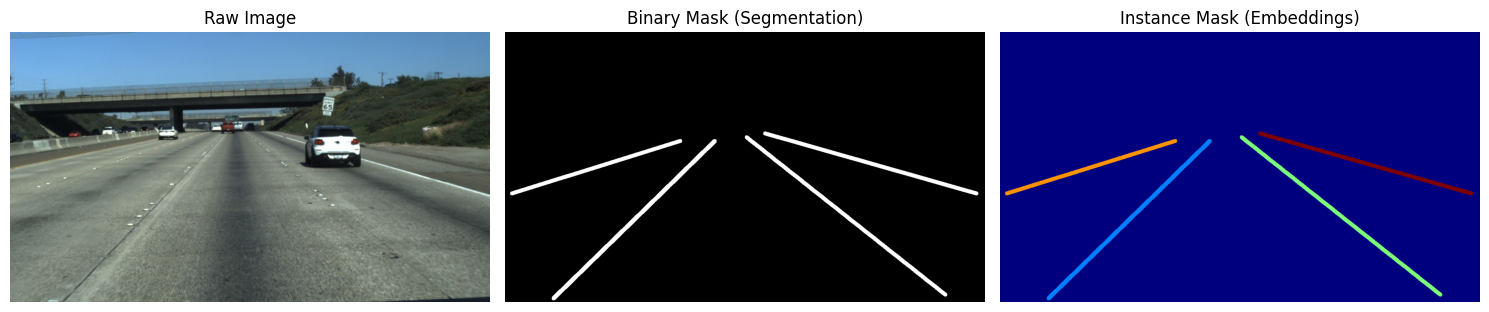

In [8]:
import matplotlib.pyplot as plt
import cv2
import os
import random

def visualize_random_sample(root_dir):
    # 1. Load the manifest
    manifest_path = os.path.join(root_dir, 'train.txt')
    with open(manifest_path, 'r') as f:
        lines = f.readlines()
    
    # 2. Pick a random entry
    random_line = random.choice(lines).strip()
    img_rel, bin_rel, inst_rel = random_line.split()
    
    # 3. Load the images
    # We use cv2.imread and convert colors because matplotlib expects RGB
    img = cv2.imread(os.path.join(root_dir, img_rel))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    
    bin_mask = cv2.imread(os.path.join(root_dir, bin_rel), cv2.IMREAD_GRAYSCALE)
    inst_mask = cv2.imread(os.path.join(root_dir, inst_rel), cv2.IMREAD_GRAYSCALE)
    
    # 4. Plotting
    plt.figure(figsize=(15, 5))
    
    plt.subplot(1, 3, 1)
    plt.imshow(img)
    plt.title("Raw Image")
    plt.axis('off')
    
    plt.subplot(1, 3, 2)
    plt.imshow(bin_mask, cmap='gray')
    plt.title("Binary Mask (Segmentation)")
    plt.axis('off')
    
    plt.subplot(1, 3, 3)
    plt.imshow(inst_mask, cmap='jet') # 'jet' helps see unique lane colors better
    plt.title("Instance Mask (Embeddings)")
    plt.axis('off')
    
    plt.tight_layout()
    plt.show()

# Execute
ROOT = "/content/drive/MyDrive/Lane_Detection_Project/data/tusimple"
visualize_random_sample(ROOT)